# 01 · Tokenização e embeddings — *Elmo*

**Construto que sai daqui:** `tokenizer` + `dataloader` + embeddings (token + posição) → entrada do notebook 02.

Perguntas que vamos responder rodando código:
1. Como seria se trocássemos o BPE por outro tokenizador?
2. E se eu quiser construir **meu** vocabulário?
3. O que acontece se mudarmos a dimensão dos embeddings?
4. Conseguimos visualizar os pesos dentro dos vetores?

In [1]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import tiktoken
import torch

from aula import the_verdict, load_gpt2
from llms_from_scratch.ch02 import create_dataloader_v1

torch.manual_seed(123)
texto = the_verdict()
frase = "Hello, class! Tokenização do GPT-2 é unbelievably interessante."
print(len(texto), "caracteres no livro de treino (the-verdict)")

20479 caracteres no livro de treino (the-verdict)


## 1. Três jeitos de quebrar texto
Vamos montar tokenizadores de **caractere** e de **palavra** a partir do *the-verdict* e comparar com o **BPE** do GPT-2.

In [2]:
# Nível caractere: vocabulário = todo caractere que apareceu no texto
vocab_char = sorted(set(texto))
fora_char = [c for c in frase if c not in vocab_char]
print("vocab caractere:", len(vocab_char), "| tokens da frase:", len(frase), "| desconhecidos:", fora_char)

# Nível palavra (igual ao SimpleTokenizer do cap. 2)
def palavras(t):
    return [p for p in re.split(r'([,.:;?_!"()\']|--|\s)', t) if p.strip()]

vocab_pal = set(palavras(texto))
tokens_pal = palavras(frase)
print("vocab palavra:", len(vocab_pal), "| tokens da frase:", len(tokens_pal),
      "| desconhecidos:", [p for p in tokens_pal if p not in vocab_pal])

# BPE do GPT-2: nunca tem token desconhecido, quebra em pedaços (subpalavras / bytes)
bpe = tiktoken.get_encoding("gpt2")
ids = bpe.encode(frase)
print("vocab BPE:", bpe.n_vocab, "| tokens da frase:", len(ids))
print([bpe.decode([i]) for i in ids])

vocab caractere: 62 | tokens da frase: 63 | desconhecidos: ['ç', 'ã', '2', 'é']
vocab palavra: 1130 | tokens da frase: 11 | desconhecidos: ['Hello', 'class', 'Tokenização', 'GPT-2', 'é', 'unbelievably', 'interessante']
vocab BPE: 50257 | tokens da frase: 20
['Hello', ',', ' class', '!', ' Token', 'iza', 'ç', 'ão', ' do', ' G', 'PT', '-', '2', ' é', ' unbelievably', ' int', 'e', 'ress', 'ante', '.']


**Leitura:** caractere → vocabulário minúsculo mas sequências longas (e o contexto enche rápido).
Palavra → sequências curtas, mas qualquer palavra nova vira `<|unk|>`.
BPE → meio-termo: vocabulário fixo (~50k) e **zero** desconhecidos, porque no pior caso cai para bytes.

### E tokenizadores mais novos? (GPT-4 = `cl100k_base`, GPT-4o = `o200k_base`)

In [3]:
frases = {
    "inglês": "The quick brown fox jumps over the lazy dog.",
    "português": "A rápida raposa marrom pula sobre o cachorro preguiçoso.",
    "código": "def soma(a, b):\n    return a + b",
}
for nome in ["gpt2", "cl100k_base", "o200k_base"]:
    enc = tiktoken.get_encoding(nome)
    contagem = {k: len(enc.encode(v)) for k, v in frases.items()}
    print(f"{nome:12s} vocab={enc.n_vocab:>7,}  tokens={contagem}")

gpt2         vocab= 50,257  tokens={'inglês': 10, 'português': 23, 'código': 16}


cl100k_base  vocab=100,277  tokens={'inglês': 10, 'português': 18, 'código': 11}


o200k_base   vocab=200,019  tokens={'inglês': 10, 'português': 15, 'código': 11}


Vocabulário maior ⇒ menos tokens por frase (principalmente fora do inglês) ⇒ mais texto cabe no contexto,
**mas** a camada de embedding e a camada de saída ficam maiores (`vocab × emb_dim` parâmetros cada).

## 2. Construindo o meu vocabulário: BPE do zero em ~20 linhas
Começa com os 256 bytes e, a cada passo, funde o **par vizinho mais frequente** em um token novo.

In [4]:
def treinar_bpe(texto, n_merges):
    ids = list(texto.encode("utf-8"))
    vocab = {i: bytes([i]) for i in range(256)}
    merges, tamanhos = {}, [len(ids)]
    for novo in range(256, 256 + n_merges):
        par = Counter(zip(ids, ids[1:])).most_common(1)[0][0]
        merges[par] = novo
        vocab[novo] = vocab[par[0]] + vocab[par[1]]
        saida, i = [], 0
        while i < len(ids):
            if i + 1 < len(ids) and (ids[i], ids[i + 1]) == par:
                saida.append(novo)
                i += 2
            else:
                saida.append(ids[i])
                i += 1
        ids = saida
        tamanhos.append(len(ids))
    return merges, vocab, tamanhos


def codificar(texto, merges):
    ids = list(texto.encode("utf-8"))
    for par, novo in merges.items():  # aplica os merges na ordem em que foram aprendidos
        saida, i = [], 0
        while i < len(ids):
            if i + 1 < len(ids) and (ids[i], ids[i + 1]) == par:
                saida.append(novo)
                i += 2
            else:
                saida.append(ids[i])
                i += 1
        ids = saida
    return ids


merges, meu_vocab, tamanhos = treinar_bpe(texto, n_merges=300)
print("primeiros tokens aprendidos:", [meu_vocab[i].decode("utf-8", "replace") for i in range(256, 276)])
print("últimos tokens aprendidos:  ", [meu_vocab[i].decode("utf-8", "replace") for i in range(536, 556)])

primeiros tokens aprendidos: ['e ', ' t', 'd ', 't ', 'in', 's ', 'he ', 'ha', ', ', 'ou', 'er', 'an', 'on', 'en', ' the ', 'y ', '. ', 'o ', 'ing', 'hi']
últimos tokens aprendidos:   ['room', 'when ', 'Stroud ', 'ough', 'Th', 'ed it', 'las', 'picture ', 'is ', 's, ', 'And ', 'say', 'ear', 'I f', 'al ', 'ous', 'fa', 'pre', 'il', 'lif']


45 tokens: ['H', 'ell', 'o', ', ', 'c', 'las', 's', '! ', 'T', 'o', 'k', 'en', 'i', 'z', 'a', '�', '�', '�', '�', 'o ', 'd', 'o ', 'G', 'P', 'T', '-', '2', ' ', '�', '�', ' ', 'un', 'b', 'el', 'i', 'ev', 'ab', 'ly ', 'in', 'ter', 'es', 's', 'ant', 'e', '.']


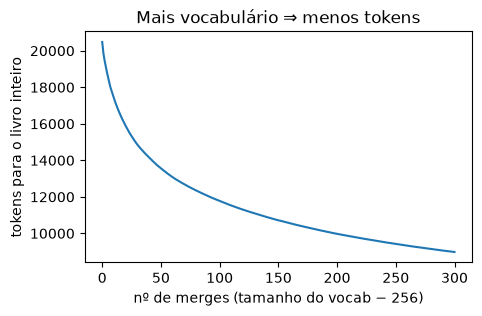

In [5]:
meus_ids = codificar(frase, merges)
print(len(meus_ids), "tokens:", [meu_vocab[i].decode("utf-8", "replace") for i in meus_ids])
assert b"".join(meu_vocab[i] for i in meus_ids).decode("utf-8") == frase  # sem perda

plt.figure(figsize=(5, 3))
plt.plot(tamanhos)
plt.xlabel("nº de merges (tamanho do vocab − 256)")
plt.ylabel("tokens para o livro inteiro")
plt.title("Mais vocabulário ⇒ menos tokens")
plt.show()

Os `�` são bytes soltos de `ç`, `ã`, `é`: o conto não tem acentos, então nosso BPE nunca aprendeu a juntá-los.
Nosso BPE foi treinado só com um conto em inglês, então funciona mal em português — exatamente o que acontece
com o `gpt2` comparado ao `o200k_base`. **O vocabulário reflete o corpus de treino.**
Versão completa (com regex de pré-tokenização como o GPT-2): `ch02/05_bpe-from-scratch/`.

## 3. Do texto para pares (entrada, alvo)
O GPT aprende a prever **o próximo token**: o alvo é a entrada deslocada 1 posição.

In [6]:
loader = create_dataloader_v1(texto, batch_size=2, max_length=4, stride=4, shuffle=False)
x, y = next(iter(loader))
print("entrada:\n", x, "\nalvo:\n", y)
for a, b in zip(x[0], y[0]):
    print(f"{bpe.decode([a.item()])!r:>12} → {bpe.decode([b.item()])!r}")

entrada:
 tensor([[  40,  367, 2885, 1464],
        [1807, 3619,  402,  271]]) 
alvo:
 tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899]])
         'I' → ' H'
        ' H' → 'AD'
        'AD' → ' always'
   ' always' → ' thought'


In [7]:
# 🔧 stride: 1 = janelas sobrepostas (mais amostras, mais repetição); = max_length = sem sobreposição
for stride in [1, 2, 4]:
    print(f"stride={stride}: {len(create_dataloader_v1(texto, batch_size=1, max_length=4, stride=stride).dataset):>5} amostras")

stride=1:  5141 amostras
stride=2:  2571 amostras
stride=4:  1286 amostras


## 4. Embeddings: cada id vira um vetor treinável
`tok_emb` é só uma tabela `vocab_size × emb_dim`; somamos um embedding de **posição** (`pos_emb`).

In [8]:
emb_dim, contexto = 768, 4
tok_emb = torch.nn.Embedding(bpe.n_vocab, emb_dim)
pos_emb = torch.nn.Embedding(contexto, emb_dim)
entrada = tok_emb(x) + pos_emb(torch.arange(contexto))
print("ids:", tuple(x.shape), "→ embeddings:", tuple(entrada.shape))

ids: (2, 4) → embeddings: (2, 4, 768)


In [9]:
# 🔧 E se mudarmos emb_dim? A tabela cresce linearmente (e o modelo inteiro ~quadraticamente, ver notebook 07)
for d in [4, 64, 768, 1024, 1600, 12288]:
    p = bpe.n_vocab * d
    print(f"emb_dim={d:>6}: {p:>13,} parâmetros só no tok_emb  ≈ {p * 4 / 1e6:8.1f} MB em float32")

emb_dim=     4:       201,028 parâmetros só no tok_emb  ≈      0.8 MB em float32
emb_dim=    64:     3,216,448 parâmetros só no tok_emb  ≈     12.9 MB em float32
emb_dim=   768:    38,597,376 parâmetros só no tok_emb  ≈    154.4 MB em float32
emb_dim=  1024:    51,463,168 parâmetros só no tok_emb  ≈    205.9 MB em float32
emb_dim=  1600:    80,411,200 parâmetros só no tok_emb  ≈    321.6 MB em float32
emb_dim= 12288:   617,558,016 parâmetros só no tok_emb  ≈   2470.2 MB em float32


Dimensão maior = mais "espaço" para codificar significado, mas mais memória e mais dados para treinar.
768 é o GPT-2 small, 1600 o XL, 12288 o GPT-3.

## 5. Visualizando os pesos dentro dos vetores
Embedding **aleatório** vs embedding **treinado** do GPT-2 (baixa os pesos oficiais uma vez, ~500 MB).

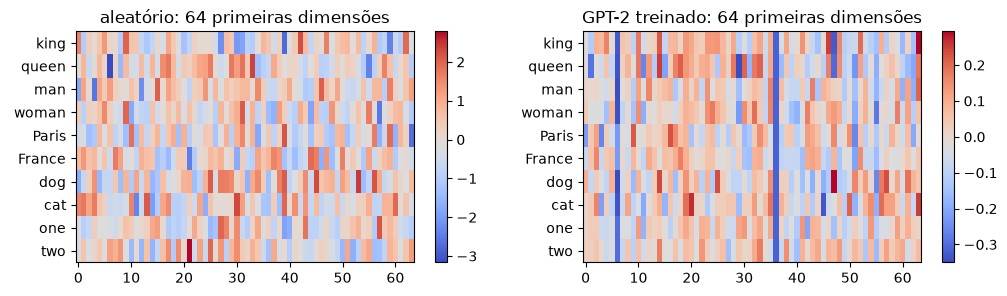

In [10]:
gpt2, _ = load_gpt2("124M")
palavras_viz = [" king", " queen", " man", " woman", " Paris", " France", " dog", " cat", " one", " two"]
ids_viz = [bpe.encode(p)[0] for p in palavras_viz]

fig, axs = plt.subplots(1, 2, figsize=(12, 3))
for ax, (nome, tabela) in zip(axs, [("aleatório", tok_emb.weight), ("GPT-2 treinado", gpt2.tok_emb.weight)]):
    im = ax.imshow(tabela[ids_viz, :64].detach(), aspect="auto", cmap="coolwarm")
    ax.set_yticks(range(len(palavras_viz)), palavras_viz)
    ax.set_title(f"{nome}: 64 primeiras dimensões")
    fig.colorbar(im, ax=ax)
plt.show()

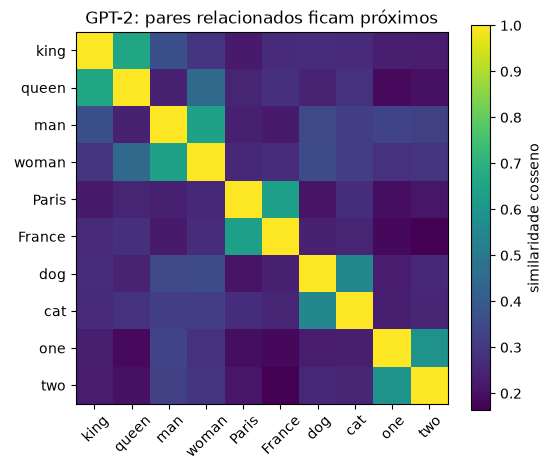

In [11]:
# Cada dimensão isolada não "significa" nada — o significado aparece na geometria: vetores parecidos = palavras parecidas
E = gpt2.tok_emb.weight[ids_viz].detach()
sim = torch.nn.functional.cosine_similarity(E[:, None], E[None, :], dim=-1)
plt.figure(figsize=(6, 5))
plt.imshow(sim, cmap="viridis")
plt.xticks(range(len(palavras_viz)), palavras_viz, rotation=45)
plt.yticks(range(len(palavras_viz)), palavras_viz)
plt.colorbar(label="similaridade cosseno")
plt.title("GPT-2: pares relacionados ficam próximos")
plt.show()

### ✅ Construto
`bpe` (tokenizer) → `create_dataloader_v1` (pares entrada/alvo) → `tok_emb + pos_emb` (tensor `batch × tokens × emb_dim`).
No notebook **02** esses vetores entram na atenção.